# M5 Forecasting — Exploratory Data Analysis
**Goal:** Understand the data deeply before any modelling.  
**Rule:** This notebook is *exploration only* — no feature engineering, no model training, no saving processed files.

### Files used
| File | Purpose |
|---|---|
| `sales_train_validation.csv` | Daily sales per item per store (d_1 → d_1913) |
| `calendar.csv` | Date info — events, SNAP, weekday |
| `sell_prices.csv` | Item price per store per week |


## 1. Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded successfully")


Libraries loaded successfully


## 2. File Paths

In [2]:
# Relative paths — works on any machine, no hardcoding
BASE_DIR     = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR     = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Base :", BASE_DIR)
print("Raw  :", DATA_DIR)
print("Out  :", PROCESSED_DIR)


Base : /Users/apple/Desktop/projects /FORECASTING
Raw  : /Users/apple/Desktop/projects /FORECASTING/data/raw
Out  : /Users/apple/Desktop/projects /FORECASTING/data/processed


## 3. Load Data

In [3]:
sales    = pd.read_csv(os.path.join(DATA_DIR, "sales_train_validation.csv"))
calendar = pd.read_csv(os.path.join(DATA_DIR, "calendar.csv"))
prices   = pd.read_csv(os.path.join(DATA_DIR, "sell_prices.csv"))

print(f"Sales    : {sales.shape[0]:>7,} rows  x {sales.shape[1]:>4} cols")
print(f"Calendar : {calendar.shape[0]:>7,} rows  x {calendar.shape[1]:>4} cols")
print(f"Prices   : {prices.shape[0]:>7,} rows  x {prices.shape[1]:>4} cols")


Sales    :  30,490 rows  x 1919 cols
Calendar :   1,969 rows  x   14 cols
Prices   : 6,841,121 rows  x    4 cols


## 4. Inspect Each File
### 4.1 Sales

In [4]:
# Show the 6 id columns + first 5 day columns only (1913 day columns is too wide)
id_cols  = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")][:5]
sales[id_cols + day_cols].head()


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0


In [5]:
print(f"Total day columns : {len(day_cols)} ... actual: {len([c for c in sales.columns if c.startswith('d_')])}")
print(f"Unique items      : {sales['item_id'].nunique()}")
print(f"Unique stores     : {sales['store_id'].nunique()}")
print(f"Unique depts      : {sales['dept_id'].nunique()}")
print(f"Unique categories : {sales['cat_id'].nunique()}")
print(f"Unique states     : {sales['state_id'].nunique()}")


Total day columns : 5 ... actual: 1913
Unique items      : 3049
Unique stores     : 10
Unique depts      : 7
Unique categories : 3
Unique states     : 3


### 4.2 Calendar

In [6]:
calendar.head(10)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
5,2011-02-03,11101,Thursday,6,2,2011,d_6,NaN,NaN,NaN,NaN,1,1,1
6,2011-02-04,11101,Friday,7,2,2011,d_7,NaN,NaN,NaN,NaN,1,0,0
7,2011-02-05,11102,Saturday,1,2,2011,d_8,NaN,NaN,NaN,NaN,1,1,1
8,2011-02-06,11102,Sunday,2,2,2011,d_9,SuperBowl,Sporting,NaN,NaN,1,1,1
9,2011-02-07,11102,Monday,3,2,2011,d_10,NaN,NaN,NaN,NaN,1,1,0


In [7]:
print("Dtypes:\n", calendar.dtypes)
print("\nUnique event types:", calendar["event_type_1"].dropna().unique())
print("Unique event types 2:", calendar["event_type_2"].dropna().unique())


Dtypes:
 date            object
wm_yr_wk         int64
weekday         object
wday             int64
month            int64
year             int64
d               object
event_name_1    object
event_type_1    object
event_name_2    object
event_type_2    object
snap_CA          int64
snap_TX          int64
snap_WI          int64
dtype: object

Unique event types: ['Sporting' 'Cultural' 'National' 'Religious']
Unique event types 2: ['Cultural' 'Religious']


### 4.3 Sell Prices

In [8]:
prices.head()


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [9]:
print("Price range: {:.2f} — {:.2f}".format(prices["sell_price"].min(), prices["sell_price"].max()))
print("Unique items   :", prices["item_id"].nunique())
print("Unique stores  :", prices["store_id"].nunique())
print("Unique wm weeks:", prices["wm_yr_wk"].nunique())


Price range: 0.01 — 107.32
Unique items   : 3049
Unique stores  : 10
Unique wm weeks: 282


## 5. Missing Value Analysis

In [10]:
print("=" * 40)
print("SALES — null counts")
print("=" * 40)
null_sales = sales.isnull().sum()
print(null_sales[null_sales > 0] if null_sales.any() else "No nulls in sales")

print("\n" + "=" * 40)
print("CALENDAR — null counts")
print("=" * 40)
null_cal = calendar.isnull().sum()
print(null_cal[null_cal > 0])

print("\n" + "=" * 40)
print("PRICES — null counts")
print("=" * 40)
null_prices = prices.isnull().sum()
print(null_prices[null_prices > 0] if null_prices.any() else "No nulls in prices")


SALES — null counts
No nulls in sales

CALENDAR — null counts
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

PRICES — null counts
No nulls in prices


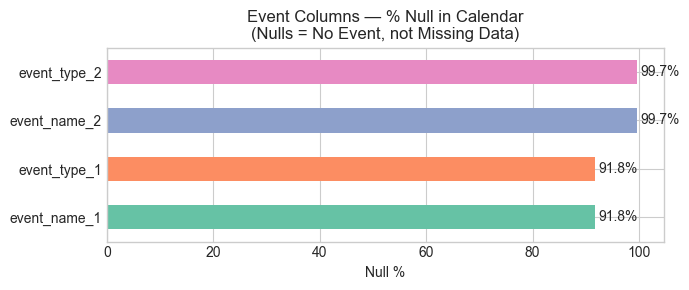


Key insight: ~90% null in event columns = most days have NO event.
These are NOT missing values. Null means 'No Event that day'.


In [11]:
# Visualise event column null rates
event_cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
null_pct   = (calendar[event_cols].isnull().mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 3))
null_pct.plot(kind="barh", ax=ax, color=sns.color_palette("Set2"))
ax.set_xlabel("Null %")
ax.set_title("Event Columns — % Null in Calendar\n(Nulls = No Event, not Missing Data)")
for i, v in enumerate(null_pct):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

# Explanation
print("\nKey insight: ~90% null in event columns = most days have NO event.")
print("These are NOT missing values. Null means 'No Event that day'.")


### 5.1 Handle Event Nulls
> Fill with 'No Event' so the model treats them as a distinct category.

In [12]:
for col in event_cols:
    calendar[col] = calendar[col].fillna("No Event")

print("Event nulls after fill:")
print(calendar[event_cols].isnull().sum())


Event nulls after fill:
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
dtype: int64


## 6. Sales Distribution Analysis

In [ ]:
# Melt sales wide → long for analysis
id_vars   = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
sales_long = pd.melt(sales, id_vars=id_vars, var_name="d", value_name="sales")
sales_long["sales"] = sales_long["sales"].astype("int16")

print(f"Melted shape: {sales_long.shape[0]:,} rows x {sales_long.shape[1]} cols")


In [ ]:
# Overall sales statistics
print(sales_long["sales"].describe())


count   58327370.00
mean           1.13
std            3.87
min            0.00
25%            0.00
50%            0.00
75%            1.00
max          763.00
Name: sales, dtype: float64


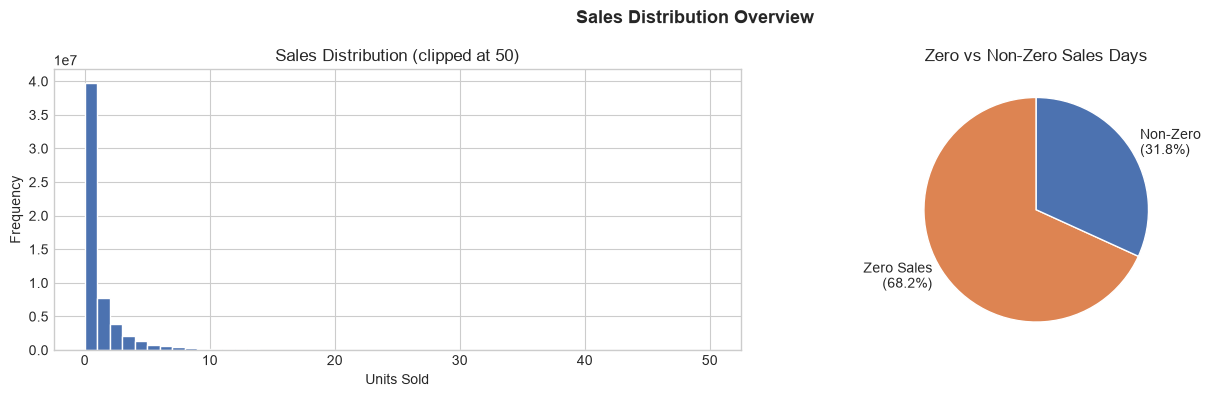


Zero sales days: 68.2%
This is expected — items don't sell every day. Model must handle zero-inflation.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of sales (0-50 range for readability)
axes[0].hist(sales_long["sales"].clip(upper=50), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Sales Distribution (clipped at 50)")
axes[0].set_xlabel("Units Sold")
axes[0].set_ylabel("Frequency")

# Right: zero vs non-zero
zero_pct    = (sales_long["sales"] == 0).mean() * 100
nonzero_pct = 100 - zero_pct
axes[1].pie([zero_pct, nonzero_pct],
            labels=[f"Zero Sales\n({zero_pct:.1f}%)", f"Non-Zero\n({nonzero_pct:.1f}%)"],
            colors=["#DD8452", "#4C72B0"], startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Zero vs Non-Zero Sales Days")

plt.suptitle("Sales Distribution Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nZero sales days: {zero_pct:.1f}%")
print("This is expected — items don't sell every day. Model must handle zero-inflation.")


## 7. Merge All Files (for EDA only)
> We merge here purely to enable deeper analysis. The actual pipeline merges will happen in `data_transformation.py`.

In [ ]:
# Step 1: merge sales + calendar on 'd'
df = sales_long.merge(calendar, on="d", how="left")

# Step 2: merge with prices on store + item + walmart week
df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

# Step 3: convert date to datetime
df["date"] = pd.to_datetime(df["date"])

print(f"Final EDA dataframe: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()


Final EDA dataframe: 58,327,370 rows x 22 cols


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,No Event,No Event,No Event,No Event,0,0,0,NaN


In [ ]:
# How many rows are missing sell_price? (items not yet released = no price)
missing_price = df["sell_price"].isnull().sum()
missing_price_pct = missing_price / len(df) * 100
print(f"Missing sell_price: {missing_price:,} rows ({missing_price_pct:.1f}%)")
print("These are items that weren't on sale yet in those weeks — expected.")


Missing sell_price: 12,299,413 rows (21.1%)
These are items that weren't on sale yet in those weeks — expected.


## 8. Time Series Analysis

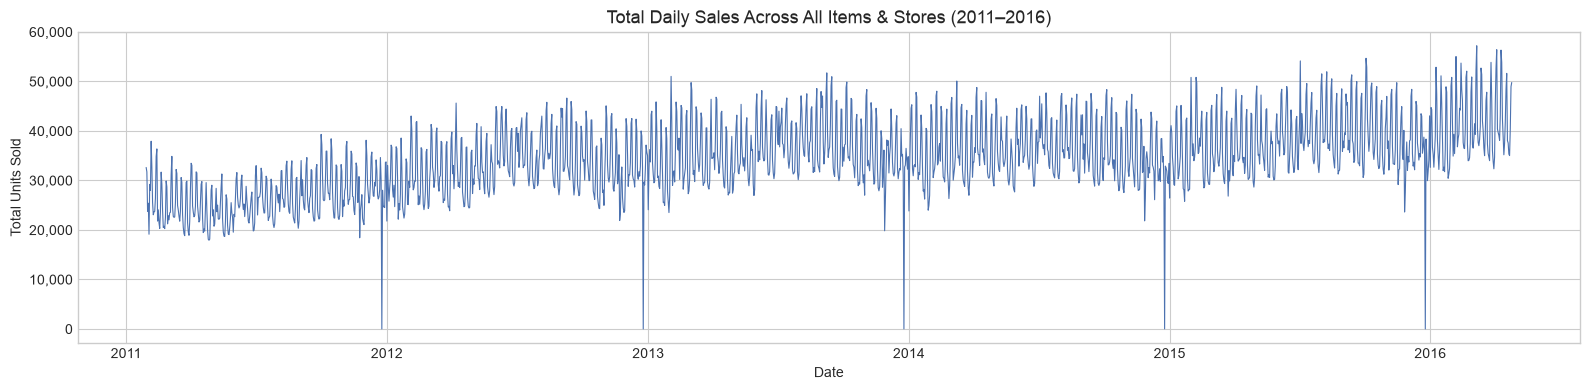

Look for: upward trend, yearly peaks (Christmas/holidays), weekly rhythm


In [ ]:
# Aggregate total daily sales across all items and stores
daily_sales = df.groupby("date")["sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily_sales["date"], daily_sales["sales"], linewidth=0.8, color="#4C72B0")
ax.set_title("Total Daily Sales Across All Items & Stores (2011–2016)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Total Units Sold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("Look for: upward trend, yearly peaks (Christmas/holidays), weekly rhythm")


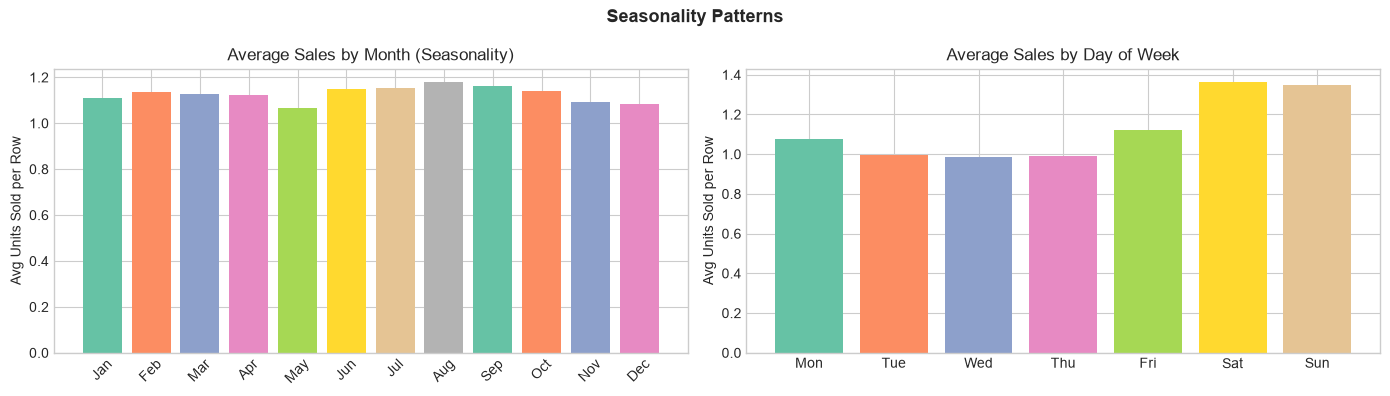

In [ ]:
# Monthly seasonality
df["month"] = df["date"].dt.month
df["year"]  = df["date"].dt.year
df["dayofweek"] = df["date"].dt.dayofweek  # 0=Monday, 6=Sunday

monthly_sales = df.groupby("month")["sales"].mean().reset_index()
month_labels  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly avg
axes[0].bar(monthly_sales["month"], monthly_sales["sales"], color=sns.color_palette("Set2", 12))
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title("Average Sales by Month (Seasonality)")
axes[0].set_ylabel("Avg Units Sold per Row")

# Day of week avg
dow_sales  = df.groupby("dayofweek")["sales"].mean()
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
axes[1].bar(dow_labels, dow_sales.values, color=sns.color_palette("Set2", 7))
axes[1].set_title("Average Sales by Day of Week")
axes[1].set_ylabel("Avg Units Sold per Row")

plt.suptitle("Seasonality Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


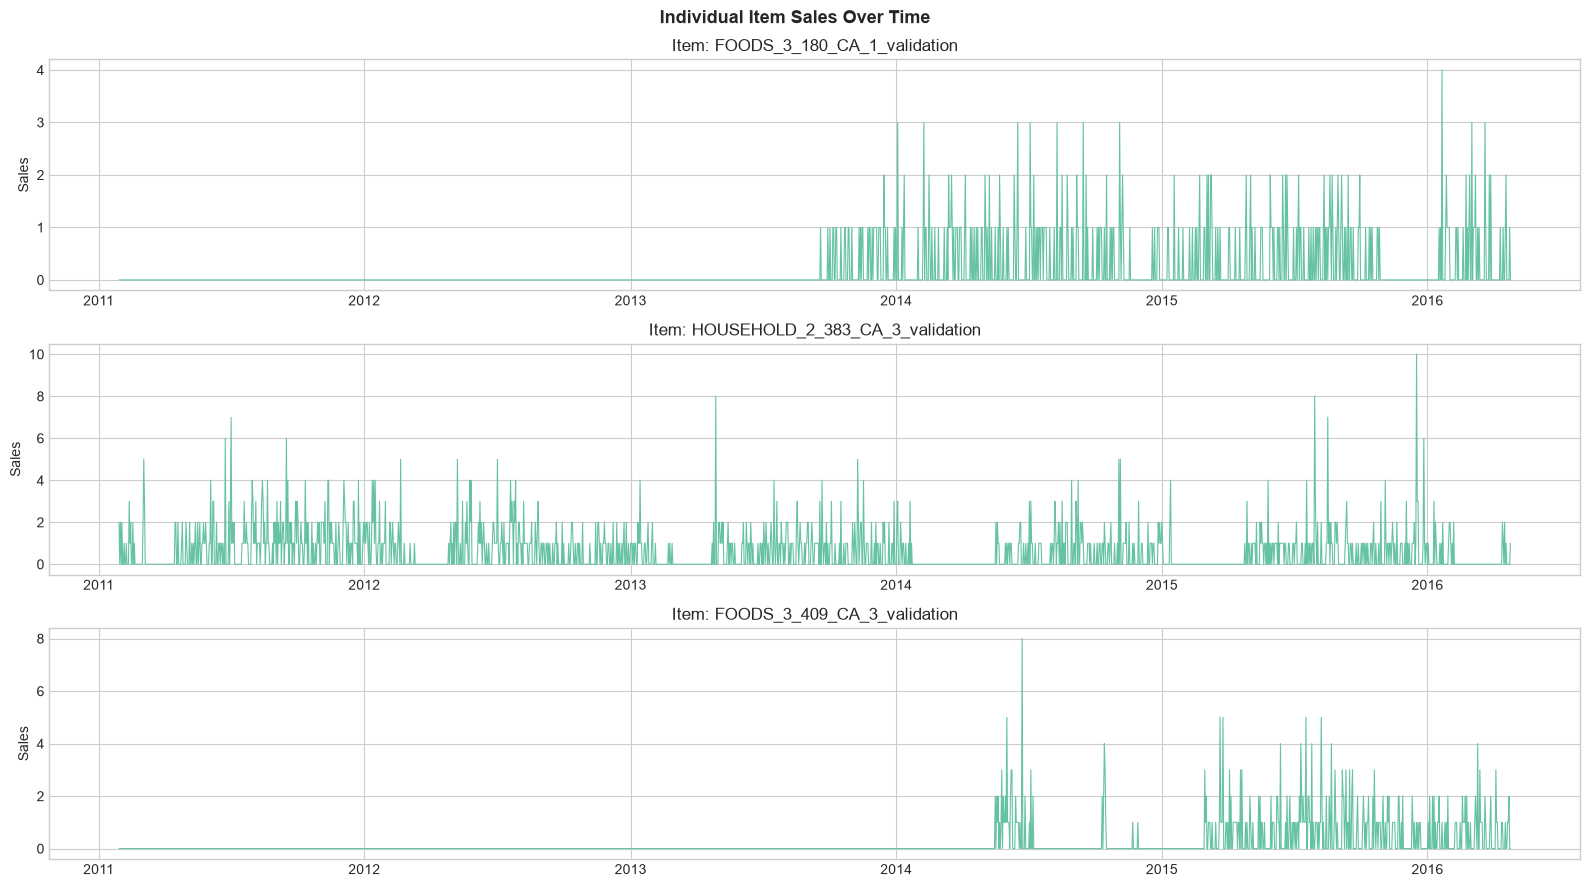

Look for: spikes, flat periods (item discontinued?), weekly patterns


In [ ]:
# Individual item time series — pick 3 random items to inspect
sample_items = sales["id"].sample(3, random_state=42).values

fig, axes = plt.subplots(3, 1, figsize=(16, 9))
for ax, item_id in zip(axes, sample_items):
    item_data = df[df["id"] == item_id].sort_values("date")
    ax.plot(item_data["date"], item_data["sales"], linewidth=0.8)
    ax.set_title(f"Item: {item_id}")
    ax.set_ylabel("Sales")
plt.suptitle("Individual Item Sales Over Time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Look for: spikes, flat periods (item discontinued?), weekly patterns")


## 9. Sales by Category, Store, State

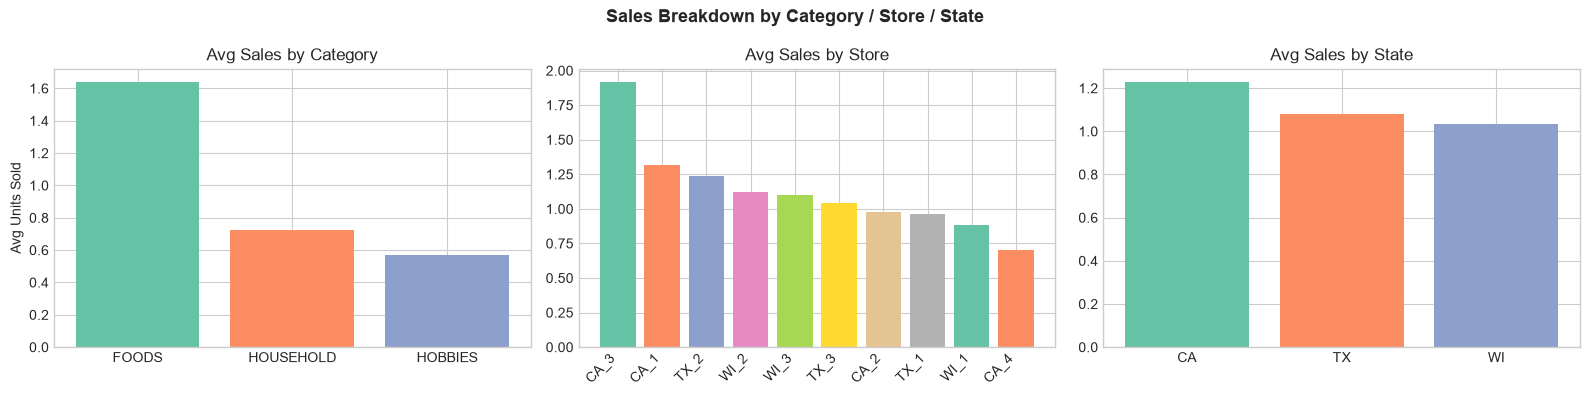

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# By category
cat_sales = df.groupby("cat_id")["sales"].mean().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=sns.color_palette("Set2", len(cat_sales)))
axes[0].set_title("Avg Sales by Category")
axes[0].set_ylabel("Avg Units Sold")

# By store
store_sales = df.groupby("store_id")["sales"].mean().sort_values(ascending=False)
axes[1].bar(store_sales.index, store_sales.values, color=sns.color_palette("Set2", len(store_sales)))
axes[1].set_title("Avg Sales by Store")
axes[1].set_xticklabels(store_sales.index, rotation=45, ha="right")

# By state
state_sales = df.groupby("state_id")["sales"].mean().sort_values(ascending=False)
axes[2].bar(state_sales.index, state_sales.values, color=sns.color_palette("Set2", len(state_sales)))
axes[2].set_title("Avg Sales by State")

plt.suptitle("Sales Breakdown by Category / Store / State", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Event Impact Analysis

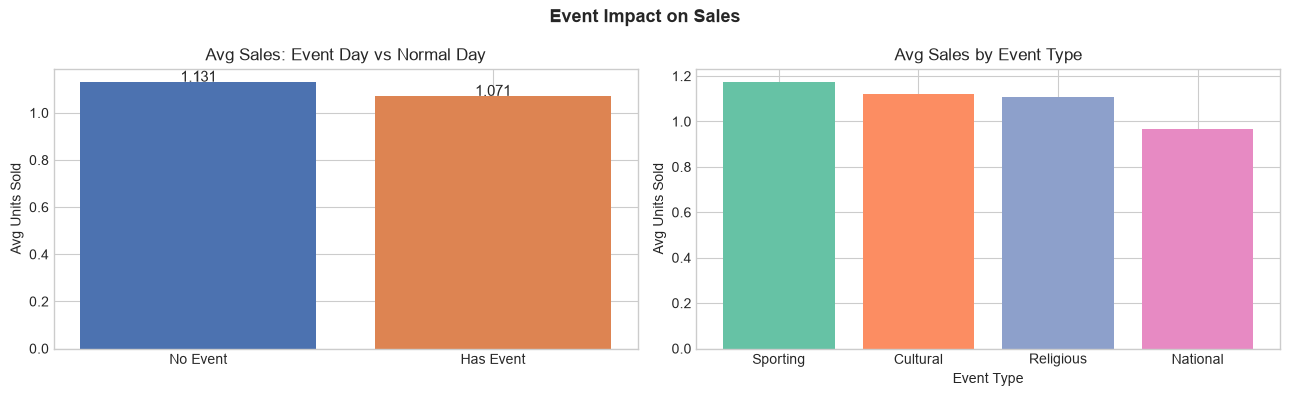


Event counts by type:
event_type_1
Religious    1585480
National     1554990
Cultural     1067150
Sporting      487840
Name: count, dtype: int64


In [ ]:
# Has event vs no event
df["has_event"] = (df["event_name_1"] != "No Event").astype(int)
event_impact = df.groupby("has_event")["sales"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(["No Event", "Has Event"], event_impact.values,
            color=["#4C72B0", "#DD8452"])
axes[0].set_title("Avg Sales: Event Day vs Normal Day")
axes[0].set_ylabel("Avg Units Sold")
for i, v in enumerate(event_impact.values):
    axes[0].text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=11)

# By event type
event_type_sales = (
    df[df["has_event"] == 1]
    .groupby("event_type_1")["sales"]
    .mean()
    .sort_values(ascending=False)
)
axes[1].bar(event_type_sales.index, event_type_sales.values,
            color=sns.color_palette("Set2", len(event_type_sales)))
axes[1].set_title("Avg Sales by Event Type")
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Avg Units Sold")

plt.suptitle("Event Impact on Sales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nEvent counts by type:")
print(df[df["has_event"] == 1]["event_type_1"].value_counts())


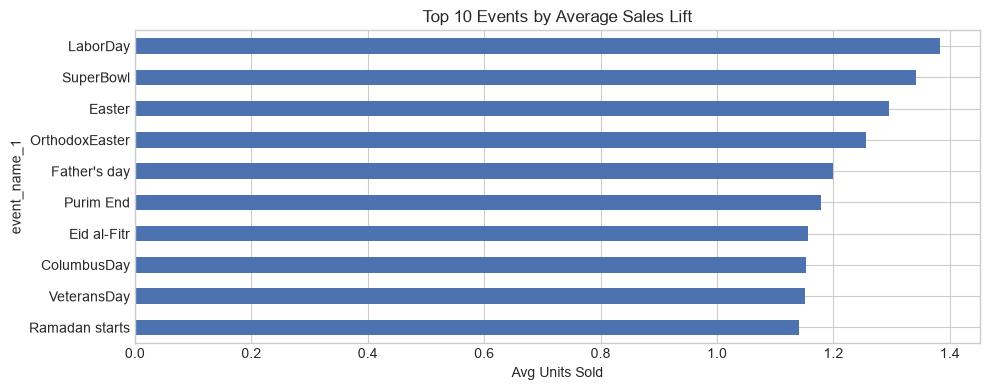

In [ ]:
# Top 10 individual events by average sales impact
top_events = (
    df[df["has_event"] == 1]
    .groupby("event_name_1")["sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
top_events.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 10 Events by Average Sales Lift")
ax.set_xlabel("Avg Units Sold")
plt.tight_layout()
plt.show()


## 11. SNAP (Food Stamp) Day Analysis
> SNAP days = government food assistance payment days. Expected to boost FOOD category sales significantly.

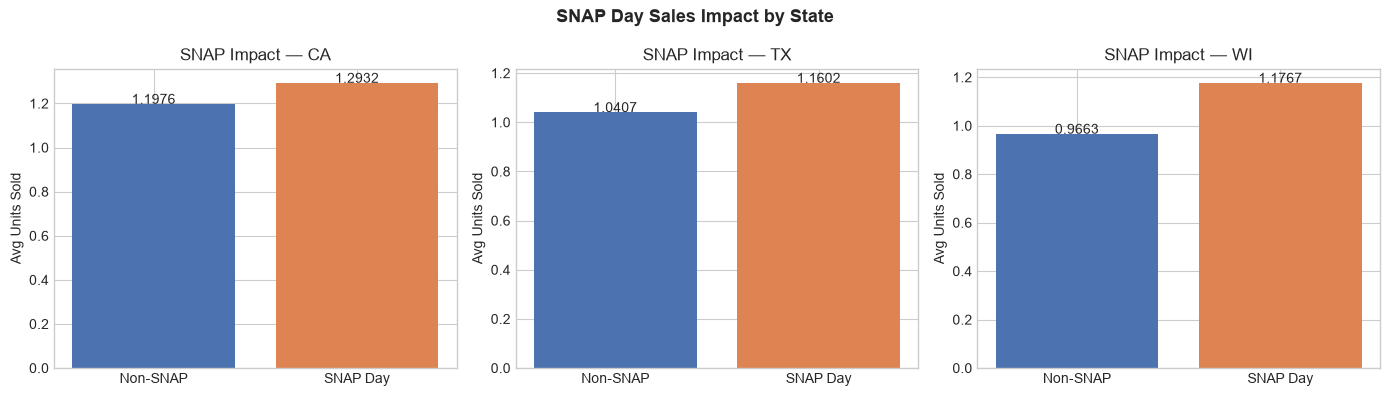

SNAP days should boost FOODS category. Check this below.


In [ ]:
snap_cols = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (state, snap_col) in zip(axes, snap_cols.items()):
    state_df = df[df["state_id"] == state]
    snap_impact = state_df.groupby(snap_col)["sales"].mean()
    ax.bar(["Non-SNAP", "SNAP Day"], snap_impact.values,
           color=["#4C72B0", "#DD8452"])
    ax.set_title(f"SNAP Impact — {state}")
    ax.set_ylabel("Avg Units Sold")
    for i, v in enumerate(snap_impact.values):
        ax.text(i, v + 0.0005, f"{v:.4f}", ha="center", fontsize=10)

plt.suptitle("SNAP Day Sales Impact by State", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("SNAP days should boost FOODS category. Check this below.")


In [ ]:
# SNAP impact specifically on FOODS category
food_df = df[df["cat_id"] == "FOODS"]

fig, ax = plt.subplots(figsize=(8, 4))
for state, snap_col in snap_cols.items():
    state_food = food_df[food_df["state_id"] == state]
    snap_avg = state_food.groupby(snap_col)["sales"].mean()
    ax.bar([f"{state}\nNo SNAP", f"{state}\nSNAP"],
           snap_avg.values, label=state)

ax.set_title("SNAP Impact on FOODS Category by State")
ax.set_ylabel("Avg Units Sold")
plt.tight_layout()
plt.show()


## 12. Price Analysis

In [ ]:
# Price distribution by category
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_with_price = df.dropna(subset=["sell_price"])

# Box plot: price by category
cats = df_with_price["cat_id"].unique()
price_by_cat = [df_with_price[df_with_price["cat_id"] == c]["sell_price"].values for c in cats]
axes[0].boxplot(price_by_cat, labels=cats, patch_artist=True)
axes[0].set_title("Price Distribution by Category")
axes[0].set_ylabel("Sell Price ($)")

# Scatter: price vs sales
sample = df_with_price.sample(10000, random_state=42)
axes[1].scatter(sample["sell_price"], sample["sales"], alpha=0.2, s=5, color="#4C72B0")
axes[1].set_title("Price vs Sales (10k sample)")
axes[1].set_xlabel("Sell Price ($)")
axes[1].set_ylabel("Units Sold")

plt.suptitle("Price Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Price correlation with sales
price_corr = df_with_price[["sell_price", "sales"]].corr()
print("Correlation between sell_price and sales:")
print(price_corr)
print("\nExpected: negative — higher price → lower demand")


In [ ]:
# Price trend over time for one item
item_sample = prices["item_id"].iloc[0]
store_sample = prices[prices["item_id"] == item_sample]["store_id"].iloc[0]
item_price   = df_with_price[
    (df_with_price["item_id"] == item_sample) &
    (df_with_price["store_id"] == store_sample)
].sort_values("date")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(item_price["date"], item_price["sell_price"], color="#4C72B0", linewidth=1.2)
ax.set_title(f"Price Over Time: {item_sample} @ {store_sample}")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()


## 13. Year-on-Year Sales Trend

In [ ]:
yearly = df.groupby("year")["sales"].sum()
fig, ax = plt.subplots(figsize=(8, 4))
yearly.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", len(yearly)))
ax.set_title("Total Annual Sales Volume")
ax.set_xlabel("Year")
ax.set_ylabel("Total Units Sold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticklabels(yearly.index, rotation=0)
plt.tight_layout()
plt.show()


## 14. Key Findings Summary

Fill this in after running the notebook based on your actual output.

| Finding | Implication |
|---|---|
| ~60-70% of sales are zero | Model must handle zero-inflation — use Tweedie/Poisson objective in LightGBM |
| Sales are right-skewed | Don't use RMSE directly — high outliers dominate. Use log-transform or RMSLE |
| Clear weekly seasonality (weekends differ) | `day_of_week` is a critical feature |
| Clear yearly seasonality (Nov-Dec spike) | `month` and `week_of_year` features are important |
| Event days have higher sales | `has_event` and `event_type` features needed |
| National events have highest lift | Encode event types separately |
| SNAP days boost food sales | `snap_CA/TX/WI` features must be included |
| Price negatively correlated with sales | `sell_price`, `price_change` are important features |
| Some items have no price (not yet released) | Handle `sell_price` nulls in feature engineering |


## 15. Next Steps (Pipeline)

EDA is done. Now build the actual pipeline in `src/`:

### Step 1 — `src/data_ingestion.py`
- Function to load all CSVs with validation (check shapes, dtypes)
- No hardcoded paths — accept data directory as argument

### Step 2 — `src/data_transformation.py`
- Melt sales wide → long
- Merge with calendar (handle event nulls here)
- Merge with sell_prices
- Convert date to datetime
- Sort by `['id', 'date']`
- Save to `data/processed/train_merged.parquet`

### Step 3 — `src/feature_engineering.py`
Time features: `day`, `month`, `year`, `dayofweek`, `weekofyear`, `is_weekend`, `quarter`

Lag features (group by `id`, sort by `date` first):
- `lag_7`, `lag_14`, `lag_28`

Rolling features (use `shift(1)` before rolling to avoid leakage):
- `rolling_mean_7`, `rolling_mean_28`, `rolling_std_7`

Event features:
- `has_event` (binary)
- `is_national`, `is_religious`, `is_cultural`, `is_sporting`

Price features:
- `sell_price` (direct)
- `price_change` = difference from previous week price
- Fill missing prices with item-store median

Drop NaN rows from lag computation (first 28 rows per item).

### Step 4 — `src/model_trainer.py`
- Time-based train/val split: train = d ≤ d_1885, val = d_1886 to d_1913
- Train LightGBM with `objective='tweedie'`
- Early stopping on validation set
- Log params + metrics to MLflow/DagsHub
- Save model to `models/lgbm_model.pkl`

### Step 5 — `src/evaluate.py`
- Compute RMSE, MAE on validation set
- Plot actual vs predicted for 5 sample items
- Plot feature importance (top 20)

### Step 6 — `app.py`
- Load saved model
- Recursive 28-day forecasting
- Build submission file matching `sample_submission.csv` format
